# Guided Value Exploration — U.S. College Cost, Debt, and Earnings
_Net price, completion, debt burden, income-band equity, selectivity, and earnings drivers across 1,934 four-year U.S. institutions_

***

**Programming Language:** Python in the Jupyter Notebook Environment

**Dataset:** [mariashatrova/u-s-college-value-analysis-ready-data](https://www.kaggle.com/datasets/mariashatrova/u-s-college-value-analysis-ready-data)

**Style counterpart:** [Guided Numeric and Text Exploration — E-Commerce](https://www.kaggle.com/code/nicapotato/guided-numeric-and-text-exploration-e-commerce)

**Code Navigation:** <br>
In the code, text after hashtags (`#`) are supportive explanations, not executed as code.

***

# Tables of Content:

**1. [Introduction](#Introduction)** <br>
**2. [Setup and Data Peek](#Setup)** <br>
**3. [Univariate Distributions](#Univariate)** <br>
**4. [Value Frontier: Earnings × Net Price](#Frontier)** <br>
**5. [Control × Region Structure](#Region)** <br>
**6. [Debt Burden](#Debt)** <br>
**7. [Equity: Income-Band Net Price and Pell](#Equity)** <br>
**8. [Selectivity: Admission Bands and SAT](#Selectivity)** <br>
**9. [Earnings Drivers: OLS + RF](#Drivers)** <br>
**10. [What It Means — Working Synthesis](#Synthesis)** <br>

# **1. Introduction:** <a id="Introduction"></a> <br>
This is an **analysis-ready extract of the U.S. Department of Education College Scorecard**: 1,934 currently-operating four-year institutions × 174 columns, where the messy federal fields have already been reconciled into engineered analytical columns with explicit status/validation labels. The value question is the spine of the notebook: *what do students pay (net price), what do they owe (debt), and what do they earn afterwards (median earnings 4 years post-completion)* — and how does that trade split by control (public / private nonprofit / private for-profit), region, family income band, and selectivity.

Key definitions: **net price** = published cost minus grant/scholarship aid for aid-receiving students; **completion rate** = share finishing within 150% of expected time; **earnings** = median earnings of completers measured 4 years after graduating. Missing cells are structural (privacy suppression or non-reporting), not random — they are kept as NaN and excluded per-analysis.

# **2. Setup and Data Peek:** <a id="Setup"></a>

In [1]:
# General
import numpy as np
import pandas as pd
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Scientific / modeling helpers
from IPython.display import display
from scipy import stats
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import kagglehub

# Set Plot Theme (same family as the guided series)
sns.set_theme(style="whitegrid")
sns.set_palette([
    "#30a2da",
    "#fc4f30",
    "#e5ae38",
    "#6d904f",
    "#8b8b8b",
])
plt.rcParams["figure.figsize"] = (11, 5)

# Warnings
import warnings
warnings.filterwarnings("ignore")

# Wide table inspection in Jupyter cell outputs
pd.set_option("display.max_columns", 999)
pd.set_option("display.width", 220)

/Users/nicapotato/Documents/repo/project/KaggleNotebooks/eda/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**Code Explanation and Reasoning:** <br>
Three buckets: *General*, *Visualization*, and *Scientific / modeling helpers*.

`pandas` / `numpy` hold the table (the analytical file ships as **parquet**, read via `pyarrow` under the hood); `matplotlib` / `seaborn` do the graphics. `LinearRegression` inside a `ColumnTransformer` pipeline and `RandomForestRegressor` support the earnings-driver ladder in section 9 — exploratory associational checks, not a production model. `kagglehub` resolves the file both on Kaggle (`/kaggle/input/...`) and locally.

The five-color palette matches the other guided notebooks so sequential plots feel like one continuous exploration.

In [2]:
# Read and Peak at Data
PARQUET_BASENAME = "college_value_final_analytical_dataset.parquet"
KAGGLE_SLUG = "mariashatrova/u-s-college-value-analysis-ready-data"

NUM_COLS = [
    "net_price_overall", "net_price_income_0_30k", "net_price_income_30_48k",
    "net_price_income_48_75k", "net_price_income_75_110k", "net_price_income_over_110k",
    "earnings_median_4yr_primary", "earnings_advantage_pct_vs_national",
    "completion_rate_150_display", "debt_median_completers", "debt_monthly_payment_10yr",
    "admission_rate_percent", "sat_average_context", "pell_share_percent",
    "undergraduate_enrollment_primary",
]
CAT_COLS = [
    "institution_control_label", "region_label", "locale_type_label",
    "admission_rate_band", "pell_share_band", "undergraduate_enrollment_size_band",
]
ID_COLS = ["INSTNM", "STABBR"]
ORDER_COLS = ["admission_rate_band_order", "undergraduate_enrollment_size_band_order"]
CONTROL_ORDER = ["Public", "Private nonprofit", "Private for-profit"]


def resolve_data_path(basename: str = PARQUET_BASENAME) -> Path:
    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        for p in kaggle_root.rglob(basename):
            return p
    local_data = Path("data") / basename
    if local_data.exists():
        return local_data
    root = Path(kagglehub.dataset_download(KAGGLE_SLUG))
    p = root / basename
    if not p.exists():
        hits = list(root.rglob(basename))
        assert hits, f"expected {basename} under {root}"
        p = hits[0]
    return p


data_path = resolve_data_path()
print("Parquet:", data_path)
raw = pd.read_parquet(data_path)
assert raw.shape == (1934, 174), raw.shape

# Curated ~25-column working panel; nullable pandas dtypes → plain float64 so seaborn / sklearn see np.nan
df = raw[ID_COLS + NUM_COLS + CAT_COLS + ORDER_COLS].copy()
for c in NUM_COLS + ORDER_COLS:
    df[c] = df[c].astype("float64")
assert set(df["institution_control_label"].unique()) == set(CONTROL_ORDER)
assert (df["net_price_overall"].dropna() > 0).all()
assert df["completion_rate_150_display"].dropna().between(0, 1).all()

print("Working panel: {} Rows, {} Columns (of 174 available)".format(*df.shape))
print("Control mix:", df["institution_control_label"].value_counts().to_dict())
display(df.sample(5, random_state=7))

Working panel: 1934 Rows, 25 Columns (of 174 available)
Control mix: {'Private nonprofit': 1197, 'Public': 595, 'Private for-profit': 142}


,INSTNM,STABBR,net_price_overall,net_price_income_0_30k,net_price_income_30_48k,net_price_income_48_75k,net_price_income_75_110k,net_price_income_over_110k,earnings_median_4yr_primary,earnings_advantage_pct_vs_national,completion_rate_150_display,debt_median_completers,debt_monthly_payment_10yr,admission_rate_percent,sat_average_context,pell_share_percent,undergraduate_enrollment_primary,institution_control_label,region_label,locale_type_label,admission_rate_band,pell_share_band,undergraduate_enrollment_size_band,admission_rate_band_order,undergraduate_enrollment_size_band_order
1412,Howard Payne University,TX,23627.0,24043.0,21423.0,25917.0,23412.0,24182.0,50567.0,0.401447,0.2798,26793.0,284.050391,67.37,1026.0,44.27,713.0,Private nonprofit,Southwest,Town,More than 50% to 75%,More than 40% to 60%,"Fewer than 1,000",3.0,1.0
1569,Lawrence University,WI,23401.0,10419.0,13332.0,15020.0,20256.0,32758.0,51503.0,0.427388,0.7677,26000.0,275.643271,63.94,1350.0,21.99,1396.0,Private nonprofit,Great Lakes,City,More than 50% to 75%,More than 20% to 40%,"1,000 to 4,999",3.0,2.0
611,Massachusetts College of Pharmacy and Health S...,MA,39545.0,35206.0,36228.0,38376.0,42536.0,43470.0,93192.0,1.582784,0.6202,25000.0,265.041607,85.21,1269.0,30.06,3451.0,Private nonprofit,New England,City,More than 75% but below 100%,More than 20% to 40%,"1,000 to 4,999",4.0,2.0
1816,DeVry University-Arizona,AZ,NaN,NaN,NaN,NaN,NaN,NaN,63172.0,0.750790,0.6667,24807.0,262.995485,NaN,NaN,40.91,6.0,Private for-profit,Southwest,City,Missing,More than 40% to 60%,"Fewer than 1,000",6.0,1.0
1850,Chamberlain University-New Jersey,NJ,37984.0,38904.0,NaN,NaN,NaN,37754.0,97262.0,1.695582,0.3333,20919.0,221.776215,100.00,NaN,38.68,1226.0,Private for-profit,Mid East,Suburb,100%,More than 20% to 40%,"1,000 to 4,999",5.0,2.0


**Code Explanation and Reasoning:** <br>
`resolve_data_path` mirrors the CSV pattern used across this series, just pointed at the parquet artifact — on Kaggle it walks `/kaggle/input`, locally it falls back to `kagglehub.dataset_download`.

Of the 174 columns, most are provenance scaffolding (source flags, validation statuses, interpretation notes). The working panel keeps the **engineered analytical fields** — the dataset author already reconciled public/private field variants into single columns like `net_price_overall` — plus the label/band columns for grouping. The one technical step that matters: the parquet ships pandas *nullable* dtypes (`Float64`/`Int64`), which are converted to plain `float64` so seaborn and sklearn receive ordinary `np.nan` missingness.

In [3]:
unique_count = [[c, df[c].nunique(dropna=False), int(df[c].isnull().sum())] for c in df.columns]
display(pd.DataFrame(unique_count, columns=["Column", "Unique", "Null"]).sort_values("Null", ascending=False))
df[["net_price_overall", "earnings_median_4yr_primary", "completion_rate_150_display",
    "debt_median_completers", "debt_monthly_payment_10yr", "pell_share_percent"]].describe().round(1)

,Column,Unique,Null
14,sat_average_context,429,926
7,net_price_income_over_110k,1515,376
13,admission_rate_percent,1354,349
6,net_price_income_75_110k,1573,313
5,net_price_income_48_75k,1610,268
4,net_price_income_30_48k,1626,248
12,debt_monthly_payment_10yr,701,216
3,net_price_income_0_30k,1689,205
11,debt_median_completers,712,192
2,net_price_overall,1715,165


,net_price_overall,earnings_median_4yr_primary,completion_rate_150_display,debt_median_completers,debt_monthly_payment_10yr,pell_share_percent
count,1769.0,1781.0,1808.0,1742.0,1718.0,1922.0
mean,21150.8,62456.5,0.5,22532.9,239.0,36.5
std,9496.0,17380.1,0.2,5364.2,56.6,18.1
min,672.0,16438.0,0.0,3591.0,38.1,0.0
25%,14356.0,52141.0,0.4,20000.0,212.0,23.7
50%,20077.0,60377.0,0.5,23250.0,246.5,33.9
75%,26502.0,70456.0,0.7,26000.0,275.6,46.1
max,73043.0,161961.0,1.0,43021.0,456.1,100.0


**Interpretation** <br>
Coverage is high but uneven, and the gaps are informative: `sat_average_context` is missing for roughly half the panel (test-optional and open-admission schools don't report), `admission_rate_percent` for ~349 (open admission), and the income-band net prices thin out at the top band (fewer high-income aid recipients to average). The core value triangle — net price (~1,769 schools), earnings (~1,781), completion (~1,808) — is well covered. Median net price sits near \$20k/year against median earnings near \$60k four years out.

# **3. Univariate Distributions:** <a id="Univariate"></a>

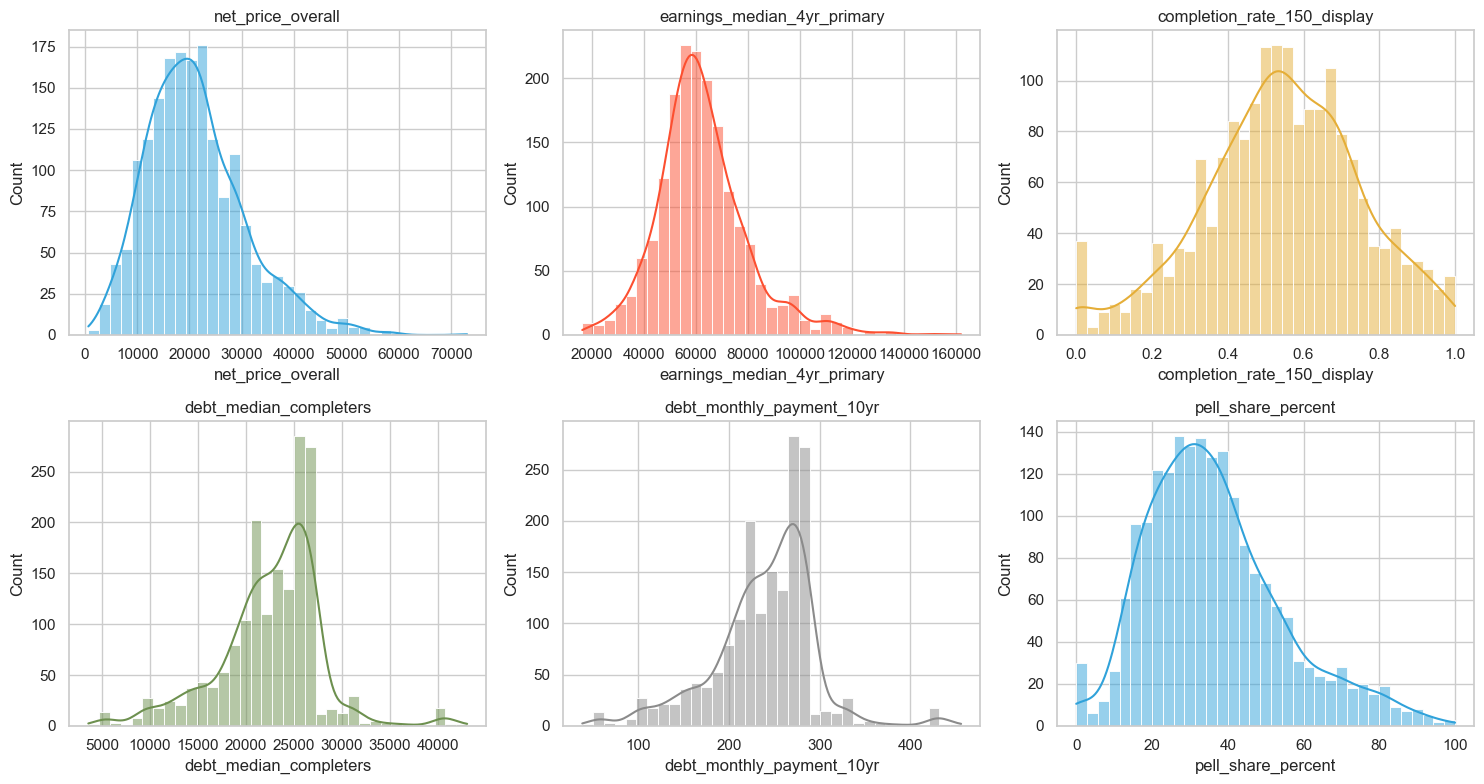

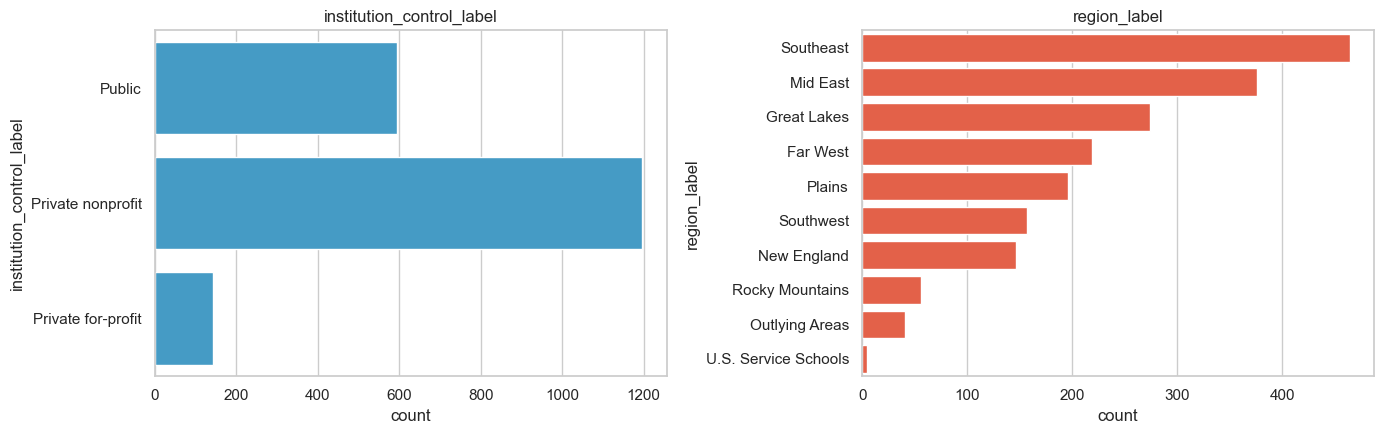

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()
for ax, col, color in [
    (axes[0], "net_price_overall", "#30a2da"),
    (axes[1], "earnings_median_4yr_primary", "#fc4f30"),
    (axes[2], "completion_rate_150_display", "#e5ae38"),
    (axes[3], "debt_median_completers", "#6d904f"),
    (axes[4], "debt_monthly_payment_10yr", "#8b8b8b"),
    (axes[5], "pell_share_percent", "#30a2da"),
]:
    sns.histplot(df[col].dropna(), bins=35, kde=True, ax=ax, color=color)
    ax.set_title(col)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.countplot(data=df, y="institution_control_label", order=CONTROL_ORDER, ax=axes[0], color="#30a2da")
axes[0].set_title("institution_control_label")
sns.countplot(data=df, y="region_label", order=df["region_label"].value_counts().index, ax=axes[1], color="#fc4f30")
axes[1].set_title("region_label")
plt.tight_layout()
plt.show()

**Interpretation** <br>
Net price is right-skewed with a long private-school tail past \$50k; earnings are right-skewed too but tighter (a \$150k+ tail of specialty schools). Completion spreads across the whole 0–1 range — a striking amount of institutional variation on the most basic outcome. Debt columns are the most bell-shaped, anchored by federal loan limits: the median completer's 10-year payment clusters around \$200–280/month. The panel is dominated by private nonprofits (~1,200) over publics (~600), with a small for-profit slice (~140) — small-n caution applies to for-profit medians throughout. Southeast and Mid East carry the most institutions.

# **4. Value Frontier: Earnings × Net Price:** <a id="Frontier"></a>

Institutions with both net price and earnings: 1670


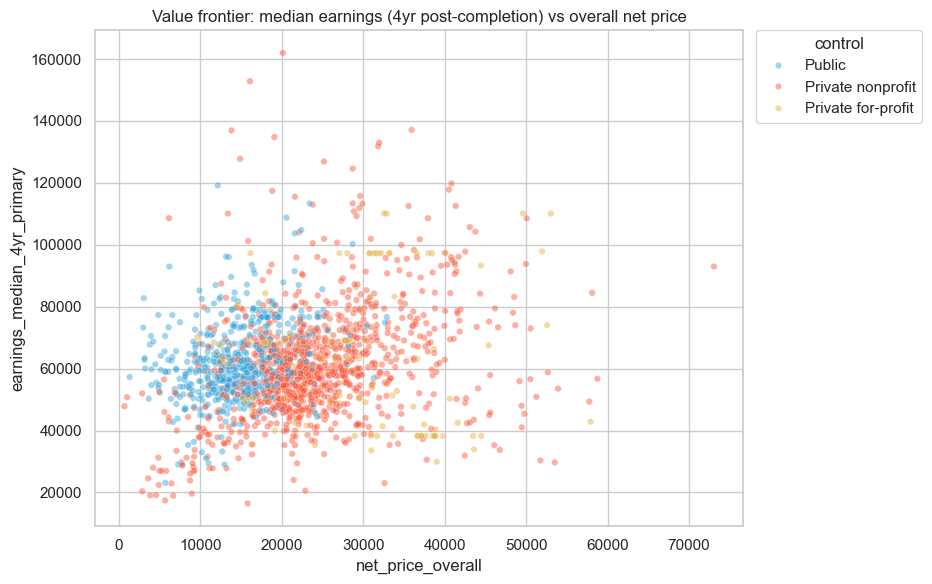

Highest earnings per net-price dollar:


,INSTNM,STABBR,institution_control_label,net_price_overall,earnings_median_4yr_primary,value_ratio
1658,College of Biblical Studies-Houston,TX,Private nonprofit,672.0,47825.0,71.17
97,San Diego Christian College,CA,Private nonprofit,992.0,50741.0,51.15
1828,Texas A&M University-Central Texas,TX,Public,1300.0,57267.0,44.05
887,CUNY Bernard M Baruch College,NY,Public,3033.0,82748.0,27.28
892,CUNY Hunter College,NY,Public,2984.0,73236.0,24.54
888,CUNY Brooklyn College,NY,Public,3103.0,62833.0,20.25
894,CUNY Lehman College,NY,Public,3148.0,63353.0,20.12
893,CUNY John Jay College of Criminal Justice,NY,Public,3203.0,60020.0,18.74
377,Trinity International University-Illinois,IL,Private nonprofit,2835.0,51985.0,18.34
1120,Ohio University-Eastern Campus,OH,Public,3925.0,70528.0,17.97


Lowest earnings per net-price dollar:


,INSTNM,STABBR,institution_control_label,net_price_overall,earnings_median_4yr_primary,value_ratio
1655,Beacon College,FL,Private nonprofit,53517.0,29712.0,0.56
923,Manhattan School of Music,NY,Private nonprofit,51754.0,30305.0,0.59
1662,Rabbinical College of Ohr Shimon Yisroel,NY,Private nonprofit,32594.0,22994.0,0.71
620,The New England Conservatory of Music,MA,Private nonprofit,46754.0,33743.0,0.72
999,School of Visual Arts,NY,Private for-profit,57914.0,42822.0,0.74
1262,Pennsylvania Academy of the Fine Arts,PA,Private nonprofit,42454.0,31901.0,0.75
92,California Institute of the Arts,CA,Private nonprofit,46080.0,35256.0,0.77
1780,New York Film Academy,CA,Private for-profit,39011.0,29902.0,0.77
1721,Los Angeles College of Music,CA,Private for-profit,43590.0,33938.0,0.78
1845,Bethany Global University,MN,Private nonprofit,37790.0,30557.0,0.81


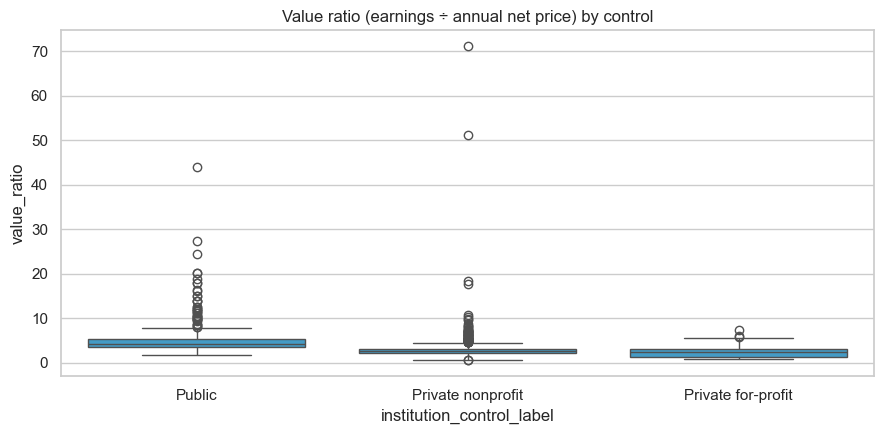

institution_control_label
Private for-profit    2.39
Private nonprofit     2.55
Public                4.18


In [5]:
val = df.dropna(subset=["net_price_overall", "earnings_median_4yr_primary"]).copy()
val["value_ratio"] = val["earnings_median_4yr_primary"] / val["net_price_overall"]
print("Institutions with both net price and earnings:", len(val))

fig, ax = plt.subplots(figsize=(9.5, 6))
sns.scatterplot(
    data=val, x="net_price_overall", y="earnings_median_4yr_primary",
    hue="institution_control_label", hue_order=CONTROL_ORDER, alpha=0.45, s=22, ax=ax,
)
ax.set_title("Value frontier: median earnings (4yr post-completion) vs overall net price")
ax.legend(title="control", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.show()

show_cols = ["INSTNM", "STABBR", "institution_control_label",
             "net_price_overall", "earnings_median_4yr_primary", "value_ratio"]
print("Highest earnings per net-price dollar:")
display(val.nlargest(10, "value_ratio")[show_cols].round(2))
print("Lowest earnings per net-price dollar:")
display(val.nsmallest(10, "value_ratio")[show_cols].round(2))

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.boxplot(data=val, x="institution_control_label", y="value_ratio", order=CONTROL_ORDER, ax=ax, color="#30a2da")
ax.set_title("Value ratio (earnings ÷ annual net price) by control")
plt.tight_layout()
plt.show()
print(val.groupby("institution_control_label", observed=True)["value_ratio"].median().round(2).to_string())

**Interpretation** <br>
The frontier scatter is diffuse — paying more buys surprisingly little extra earnings on average. The correlation between net price and later earnings is weakly positive at best, and the clouds separate by control: publics cluster at low net price with mid earnings (high value ratios), private nonprofits spread across the whole price axis at similar earnings levels. The value-ratio extremes table is the actionable artifact: the top is dominated by heavily-subsidized publics (five CUNY campuses in the top ten) plus a few tiny religious colleges with near-zero net price, while the bottom is almost entirely expensive arts and music conservatories whose graduates earn modestly — a reminder the ratio prices earnings, not artistic mission. One caveat baked into the ratio: net price is *annual*, earnings are a single post-completion year, so the ratio compares one year of cost to one year of income — a relative screen, not a full ROI.

# **5. Control × Region Structure:** <a id="Region"></a>

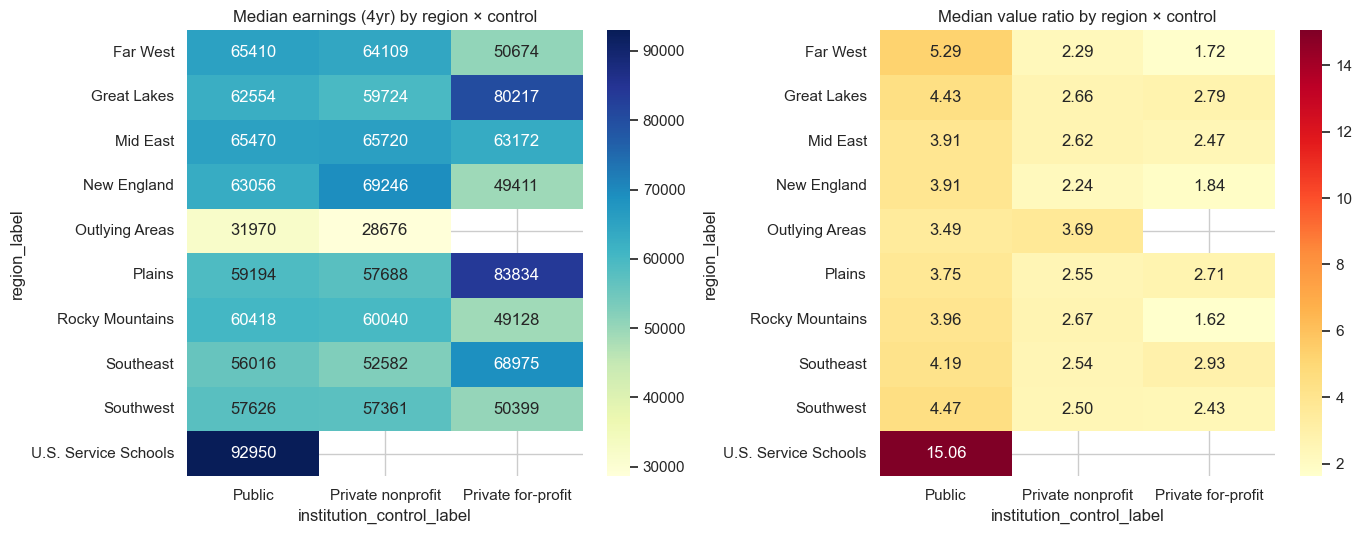

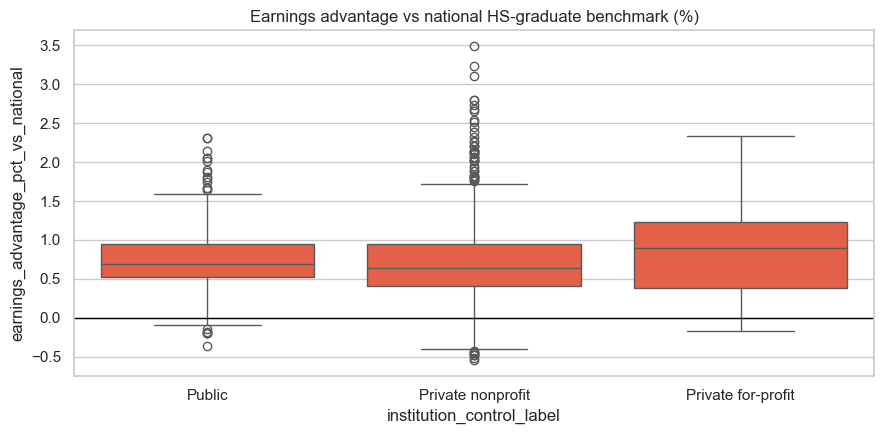

Share of institutions beating the national benchmark: 0.959


In [6]:
pivot_earn = val.pivot_table(index="region_label", columns="institution_control_label",
                             values="earnings_median_4yr_primary", aggfunc="median", observed=True)
pivot_val = val.pivot_table(index="region_label", columns="institution_control_label",
                            values="value_ratio", aggfunc="median", observed=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
sns.heatmap(pivot_earn.reindex(columns=CONTROL_ORDER), annot=True, fmt=".0f", cmap="YlGnBu", ax=axes[0])
axes[0].set_title("Median earnings (4yr) by region × control")
sns.heatmap(pivot_val.reindex(columns=CONTROL_ORDER), annot=True, fmt=".2f", cmap="YlOrRd", ax=axes[1])
axes[1].set_title("Median value ratio by region × control")
plt.tight_layout()
plt.show()

adv = df.dropna(subset=["earnings_advantage_pct_vs_national"])
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.boxplot(data=adv, x="institution_control_label", y="earnings_advantage_pct_vs_national",
            order=CONTROL_ORDER, ax=ax, color="#fc4f30")
ax.axhline(0, color="black", lw=1)
ax.set_title("Earnings advantage vs national HS-graduate benchmark (%)")
plt.tight_layout()
plt.show()
print("Share of institutions beating the national benchmark:",
      round(float((adv["earnings_advantage_pct_vs_national"] > 0).mean()), 3))

**Interpretation** <br>
Region moves earnings mostly through cost-of-living and industry mix — New England and Mid East lead on raw earnings — but the **value-ratio heatmap tells a different story**: public institutions post the best earnings-per-dollar in nearly every region because their net-price denominator is so much lower. The benchmark box plot reframes "is college worth it": the large majority of institutions graduate students earning more than the national high-school-graduate benchmark, but the below-zero tail is real and concentrated in the for-profit and small-private segments. Cells resting on few schools (for-profits in small regions) should be read loosely.

# **6. Debt Burden:** <a id="Debt"></a>

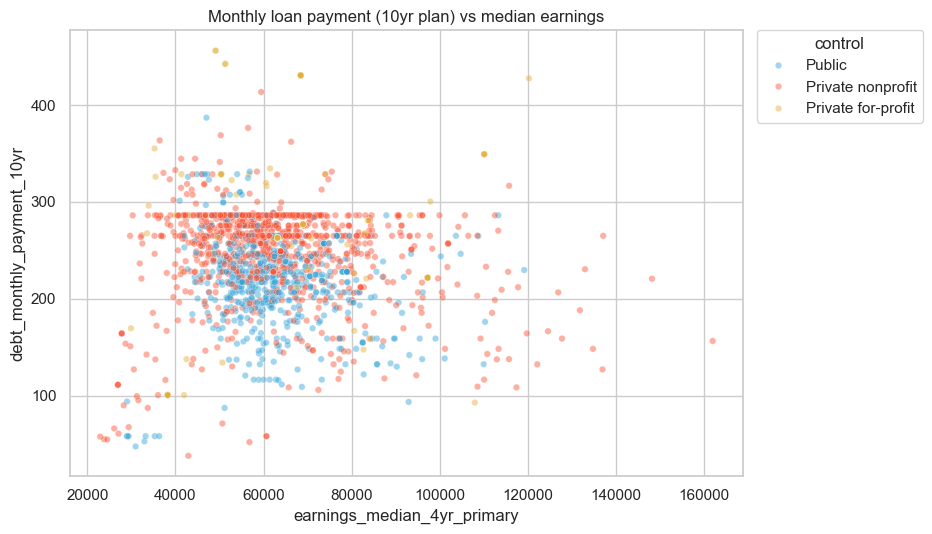

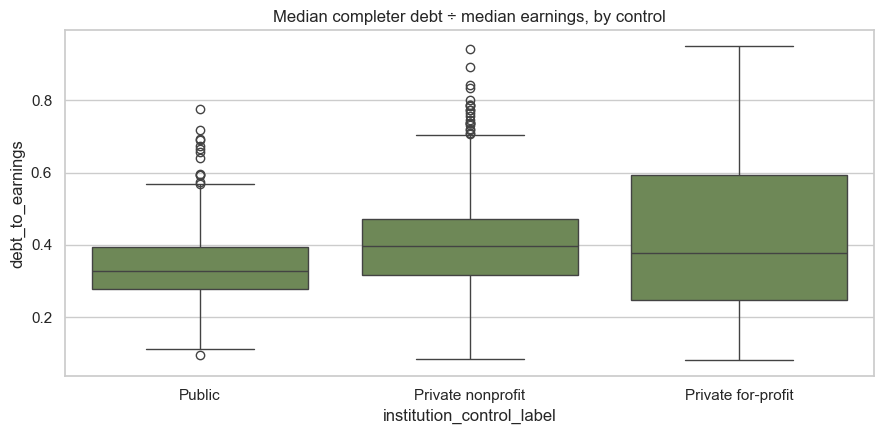

Medians by control:
                           debt_median_completers  debt_monthly_payment_10yr  debt_to_earnings
institution_control_label                                                                     
Private for-profit                        25051.5                    265.588             0.379
Private nonprofit                         24994.0                    264.978             0.396
Public                                    21000.0                    222.635             0.329


In [7]:
debt = df.dropna(subset=["debt_monthly_payment_10yr", "earnings_median_4yr_primary", "debt_median_completers"]).copy()
debt["debt_to_earnings"] = debt["debt_median_completers"] / debt["earnings_median_4yr_primary"]

fig, ax = plt.subplots(figsize=(9.5, 5.5))
sns.scatterplot(
    data=debt, x="earnings_median_4yr_primary", y="debt_monthly_payment_10yr",
    hue="institution_control_label", hue_order=CONTROL_ORDER, alpha=0.45, s=22, ax=ax,
)
ax.set_title("Monthly loan payment (10yr plan) vs median earnings")
ax.legend(title="control", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.boxplot(data=debt, x="institution_control_label", y="debt_to_earnings", order=CONTROL_ORDER, ax=ax, color="#6d904f")
ax.set_title("Median completer debt ÷ median earnings, by control")
plt.tight_layout()
plt.show()

print("Medians by control:")
print(debt.groupby("institution_control_label", observed=True)[
    ["debt_median_completers", "debt_monthly_payment_10yr", "debt_to_earnings"]
].median().round(3).to_string())

**Interpretation** <br>
Debt is remarkably flat across the earnings axis — the scatter shows monthly payments boxed into a \$150–350 band regardless of whether graduates earn \$40k or \$100k, a signature of federal loan limits capping the numerator. That flatness makes **debt-to-earnings mostly an earnings story**: institutions with low graduate earnings carry the heaviest relative burden. By control, publics run the lowest debt-to-earnings medians; the for-profit segment shows the widest and highest-risk spread. Note this is *completer* debt — dropouts with debt and no degree, arguably the worst outcome, are outside this frame.

# **7. Equity: Income-Band Net Price and Pell:** <a id="Equity"></a>

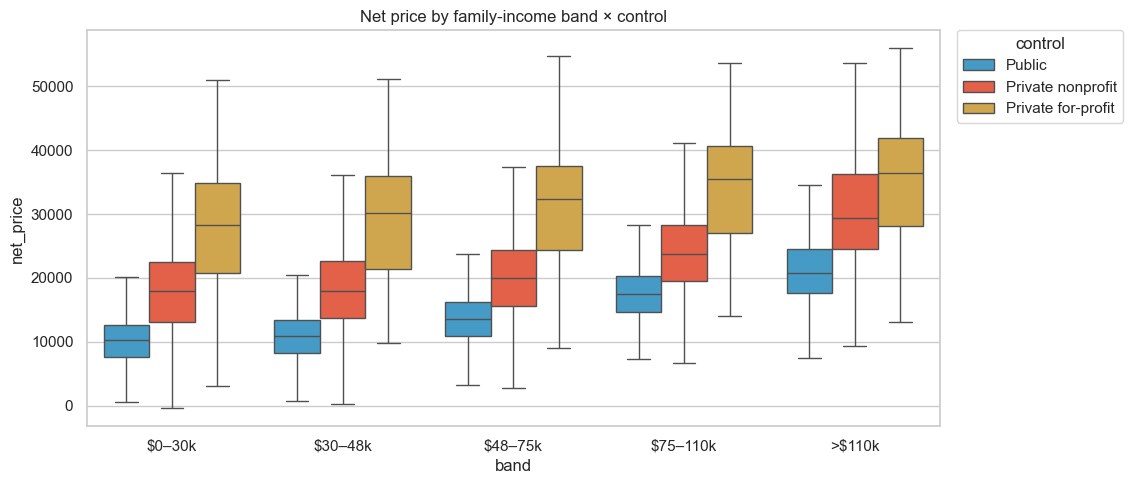

Median net-price spread (>$110k minus $0–30k) by control:
institution_control_label
Private for-profit     6482.0
Private nonprofit      9526.0
Public                10468.0


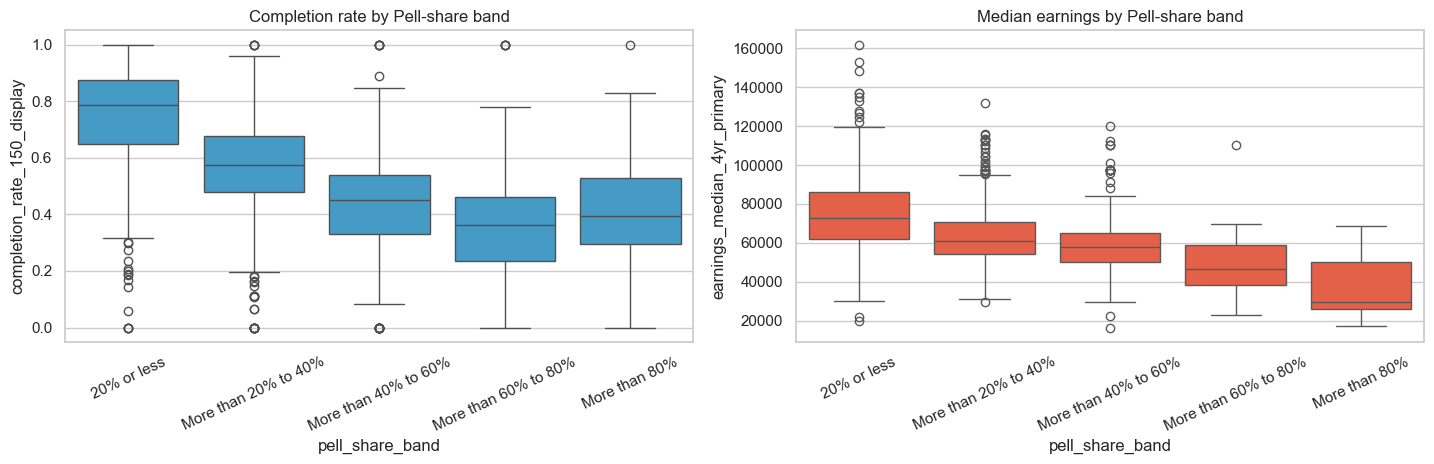

In [8]:
INCOME_BAND_LABELS = {
    "net_price_income_0_30k": "$0–30k",
    "net_price_income_30_48k": "$30–48k",
    "net_price_income_48_75k": "$48–75k",
    "net_price_income_75_110k": "$75–110k",
    "net_price_income_over_110k": ">$110k",
}
band_order = list(INCOME_BAND_LABELS.values())
melt = df[list(INCOME_BAND_LABELS) + ["institution_control_label"]].melt(
    id_vars="institution_control_label", var_name="band", value_name="net_price",
).dropna(subset=["net_price"])
melt["band"] = melt["band"].map(INCOME_BAND_LABELS)

fig, ax = plt.subplots(figsize=(11.5, 5))
sns.boxplot(data=melt, x="band", y="net_price", order=band_order,
            hue="institution_control_label", hue_order=CONTROL_ORDER, ax=ax, showfliers=False)
ax.set_title("Net price by family-income band × control")
ax.legend(title="control", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.show()

# Progressivity spread: what the richest band pays minus what the poorest band pays
prog = df.dropna(subset=["net_price_income_0_30k", "net_price_income_over_110k"]).copy()
prog["income_band_spread"] = prog["net_price_income_over_110k"] - prog["net_price_income_0_30k"]
print("Median net-price spread (>$110k minus $0–30k) by control:")
print(prog.groupby("institution_control_label", observed=True)["income_band_spread"].median().round(0).to_string())

PELL_ORDER = ["20% or less", "More than 20% to 40%", "More than 40% to 60%",
              "More than 60% to 80%", "More than 80%"]
pell = df.dropna(subset=["pell_share_band"])
fig, axes = plt.subplots(1, 2, figsize=(14.5, 4.8))
sns.boxplot(data=pell.dropna(subset=["completion_rate_150_display"]), x="pell_share_band",
            y="completion_rate_150_display", order=PELL_ORDER, ax=axes[0], color="#30a2da")
axes[0].set_title("Completion rate by Pell-share band")
axes[0].tick_params(axis="x", rotation=25)
sns.boxplot(data=pell.dropna(subset=["earnings_median_4yr_primary"]), x="pell_share_band",
            y="earnings_median_4yr_primary", order=PELL_ORDER, ax=axes[1], color="#fc4f30")
axes[1].set_title("Median earnings by Pell-share band")
axes[1].tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

**Interpretation** <br>
Aid pricing is progressive almost everywhere: the richest income band pays a median of roughly \$9.5–10.5k more per year than the poorest band at both publics and private nonprofits, versus only ~\$6.5k at for-profits. In *relative* terms publics are the most progressive — that spread is enormous against their low base price — while at nonprofits it is a modest discount off a high sticker. The Pell panels expose the equity gradient on outcomes: institutions serving mostly low-income students (high Pell bands) post systematically lower completion and earnings. That is a composition-plus-resources pattern, not an institutional quality verdict — but it is exactly where value-per-dollar arguments get tested hardest.

# **8. Selectivity: Admission Bands and SAT:** <a id="Selectivity"></a>

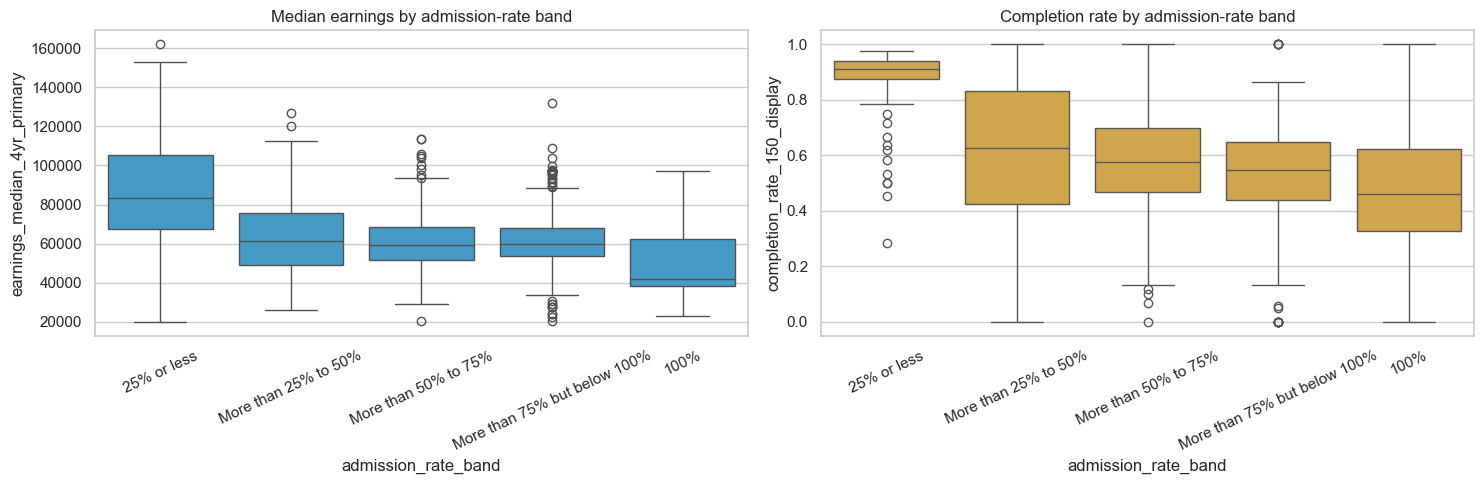

SAT reporters by control: {'Private nonprofit': 579, 'Public': 407, 'Private for-profit': 3} → lmplot keeps: ['Private nonprofit', 'Public']


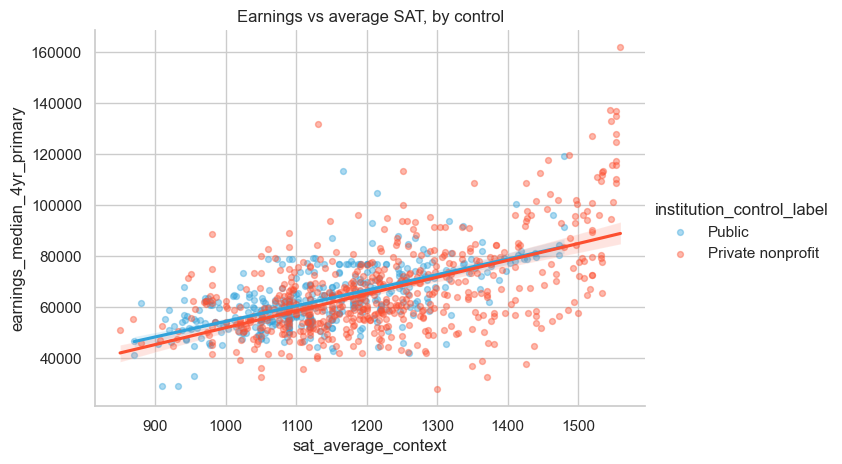

In [9]:
ADM_ORDER = (
    df[["admission_rate_band", "admission_rate_band_order"]]
    .drop_duplicates().sort_values("admission_rate_band_order")["admission_rate_band"].tolist()
)
adm_plot_order = [b for b in ADM_ORDER if b != "Missing"]
adm = df[df["admission_rate_band"] != "Missing"]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(data=adm.dropna(subset=["earnings_median_4yr_primary"]), x="admission_rate_band",
            y="earnings_median_4yr_primary", order=adm_plot_order, ax=axes[0], color="#30a2da")
axes[0].set_title("Median earnings by admission-rate band")
axes[0].tick_params(axis="x", rotation=25)
sns.boxplot(data=adm.dropna(subset=["completion_rate_150_display"]), x="admission_rate_band",
            y="completion_rate_150_display", order=adm_plot_order, ax=axes[1], color="#e5ae38")
axes[1].set_title("Completion rate by admission-rate band")
axes[1].tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

sat = df.dropna(subset=["sat_average_context", "earnings_median_4yr_primary"]).copy()
grp_n = sat["institution_control_label"].value_counts()
keep = grp_n[grp_n >= 30].index.tolist()
print("SAT reporters by control:", grp_n.to_dict(), "→ lmplot keeps:", keep)
g = sns.lmplot(
    data=sat[sat["institution_control_label"].isin(keep)],
    x="sat_average_context", y="earnings_median_4yr_primary",
    hue="institution_control_label", hue_order=[c for c in CONTROL_ORDER if c in keep],
    height=4.6, aspect=1.5, scatter_kws={"alpha": 0.4, "s": 18},
)
g.ax.set_title("Earnings vs average SAT, by control")
plt.show()

**Interpretation** <br>
Selectivity pays, but non-linearly: the "25% or less" admission band separates sharply upward on both earnings and completion, while the three broad-access bands are hard to tell apart — most of the selectivity signal lives in the elite tail. The SAT lmplot says the same thing continuously: earnings climb with the academic profile of the incoming class, with private nonprofits showing the steeper slope. The standard caveat is selection, not treatment — selective schools admit students who were already on high-earnings trajectories, so none of this isolates institutional value-add. For-profits barely report SAT and are filtered from the fit.

# **9. Earnings Drivers: OLS + RF:** <a id="Drivers"></a>

Model n = 1604 of 1934 institutions


,split,R2,RMSE
0,train,0.356,12911.744
1,test,0.336,13009.278


Top |OLS coef| (dollars of earnings; numerics per 1 SD, dummies vs 'Private for-profit' reference):


,coef
region_label_Outlying Areas,-21072.0
institution_control_label_Private nonprofit,-12614.0
institution_control_label_Public,-12559.0
locale_type_label_Town,-6092.0
locale_type_label_Rural,-5110.0
region_label_Rocky Mountains,-4915.0
pell_share_percent,-4321.0
region_label_Mid East,3839.0
region_label_Plains,-3638.0
region_label_Southeast,-3484.0


RF test R^2: 0.531


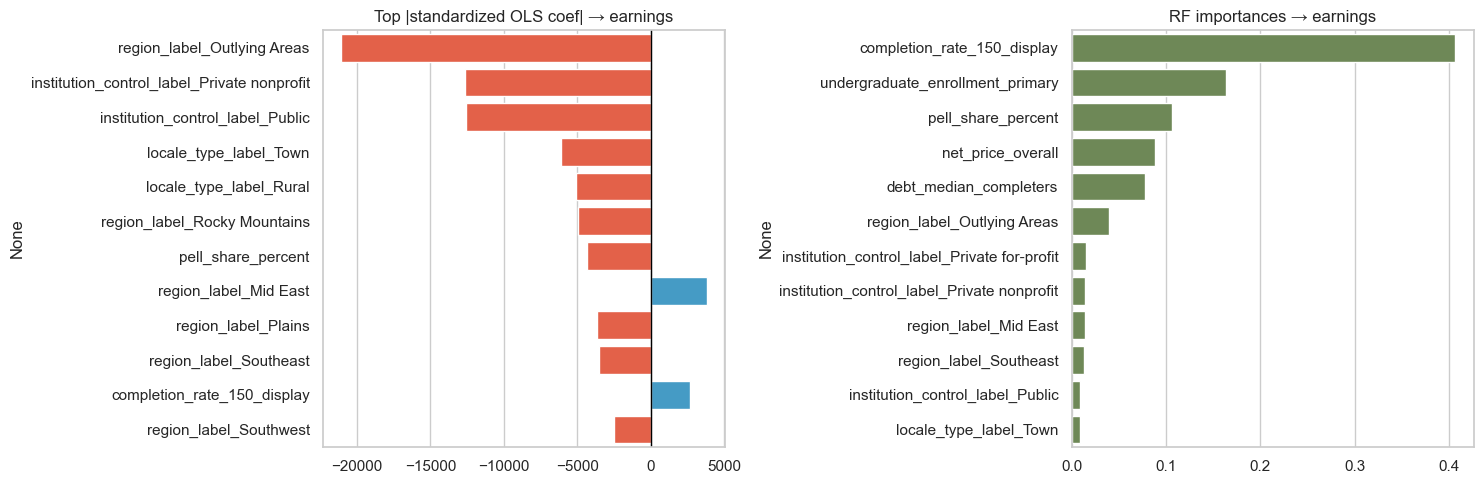

In [10]:
# Standardized OLS + RF for median earnings — associational ranking, not causal
FEATURE_NUM = ["net_price_overall", "completion_rate_150_display", "pell_share_percent",
               "undergraduate_enrollment_primary", "debt_median_completers"]
FEATURE_CAT = ["institution_control_label", "region_label", "locale_type_label"]
TARGET = "earnings_median_4yr_primary"

model_df = df.dropna(subset=FEATURE_NUM + [TARGET]).copy()
print("Model n =", len(model_df), "of", len(df), "institutions")
X = model_df[FEATURE_NUM + FEATURE_CAT]
y = model_df[TARGET]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=7)

pre = ColumnTransformer([
    ("num", StandardScaler(), FEATURE_NUM),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), FEATURE_CAT),
])
pipe_lr = Pipeline([("pre", pre), ("lr", LinearRegression())])
pipe_lr.fit(X_train, y_train)
pred_tr, pred_te = pipe_lr.predict(X_train), pipe_lr.predict(X_test)
metrics = pd.DataFrame({
    "split": ["train", "test"],
    "R2": [r2_score(y_train, pred_tr), r2_score(y_test, pred_te)],
    "RMSE": [float(np.sqrt(mean_squared_error(y_train, pred_tr))),
             float(np.sqrt(mean_squared_error(y_test, pred_te)))],
})
display(metrics.round(3))

enc = pipe_lr.named_steps["pre"]
lr = pipe_lr.named_steps["lr"]
feat_names = FEATURE_NUM + list(enc.named_transformers_["cat"].get_feature_names_out(FEATURE_CAT))
coef = pd.Series(lr.coef_, index=feat_names).sort_values(key=np.abs, ascending=False)
top_coef = coef.head(12)
print("Top |OLS coef| (dollars of earnings; numerics per 1 SD, dummies vs 'Private for-profit' reference):")
display(top_coef.rename("coef").to_frame().round(0))

pre_rf = ColumnTransformer([
    ("num", "passthrough", FEATURE_NUM),
    ("cat", OneHotEncoder(handle_unknown="ignore"), FEATURE_CAT),
])
pipe_rf = Pipeline([
    ("pre", pre_rf),
    ("rf", RandomForestRegressor(n_estimators=300, max_depth=12, random_state=7, n_jobs=-1)),
])
pipe_rf.fit(X_train, y_train)
rf = pipe_rf.named_steps["rf"]
names_rf = FEATURE_NUM + list(pipe_rf.named_steps["pre"].named_transformers_["cat"].get_feature_names_out(FEATURE_CAT))
imp = pd.Series(rf.feature_importances_, index=names_rf).sort_values(ascending=False).head(12)
print("RF test R^2:", round(r2_score(y_test, pipe_rf.predict(X_test)), 3))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(x=top_coef.values, y=top_coef.index, ax=axes[0],
            palette=["#30a2da" if v >= 0 else "#fc4f30" for v in top_coef.values])
axes[0].axvline(0, color="black", lw=1)
axes[0].set_title("Top |standardized OLS coef| → earnings")
sns.barplot(x=imp.values, y=imp.index, ax=axes[1], color="#6d904f")
axes[1].set_title("RF importances → earnings")
plt.tight_layout()
plt.show()

**Interpretation** <br>
The two models tell usefully different stories. The **RF concentrates on completion rate** (importance ≈ 0.41, more than the next three features combined), with enrollment size and Pell share next and net price only fourth — what an institution charges predicts graduate earnings far more weakly than whether its students finish. The **OLS spreads its weight across control and region dummies** (both public and nonprofit carry large negative coefficients *relative to the for-profit reference*, a conditional quirk worth not over-reading) plus a clear negative Pell-share effect. The RF's test R² (≈ 0.53) comfortably beats the OLS (≈ 0.34), so the completion–earnings relationship is substantially non-linear — consistent with the elite-tail effects from section 8. SAT was deliberately left out; it would halve the sample.

# **10. What It Means — Working Synthesis:** <a id="Synthesis"></a>

**What the table is:** <br>
An analysis-ready College Scorecard extract: 1,934 four-year U.S. institutions with reconciled net price, debt, earnings, completion, selectivity, and equity fields.

**Working takeaways:** <br>
- The value frontier is diffuse: net price predicts graduate earnings only weakly; publics dominate the earnings-per-dollar ratio in nearly every region.
- ~96% of institutions beat the national high-school-earnings benchmark; the below-benchmark tail is small but real.
- Debt is compressed by federal loan limits (median payments ~\$220–265/month), so debt-to-earnings risk is driven by the earnings side; publics post the lowest ratios and for-profits the widest spread.
- Aid pricing is progressive everywhere (~\$9.5–10.5k median rich-poor spread at publics and nonprofits, ~\$6.5k at for-profits); high-Pell institutions post systematically lower completion and earnings — the equity fault line of the panel.
- Selectivity signal is concentrated in the "25% or less" elite band; broad-access bands are nearly indistinguishable.
- The RF (test R² ≈ 0.53 vs OLS 0.34) puts completion rate far ahead of price as an earnings associate — completion and composition, not cost, carry the signal, and the relationship is non-linear.

**Open follow-ups:** <br>
- Re-run the value ratio with net price × 4 (a degree-cost approximation) and a multi-year earnings stream.
- Add the dropout side: debt-without-degree risk using withdrawal debt fields available in the full 174-column table.
- State-level fixed effects: how much of the region pattern is cost-of-living?
- Quantile regression on earnings — do the drivers differ at the 10th vs 90th percentile of institutional outcomes?
- Interaction: does completion's earnings association weaken at high Pell shares?